In [1]:
import pandas as pd
import numpy as np

In [2]:
# Dataset is the same as the 01-intro, so we can use it again
df = pd.read_csv('../01-intro/car_fuel_efficiency_2026.csv')

# Keep only the requested columns
cols = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df[cols]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


<Axes: >

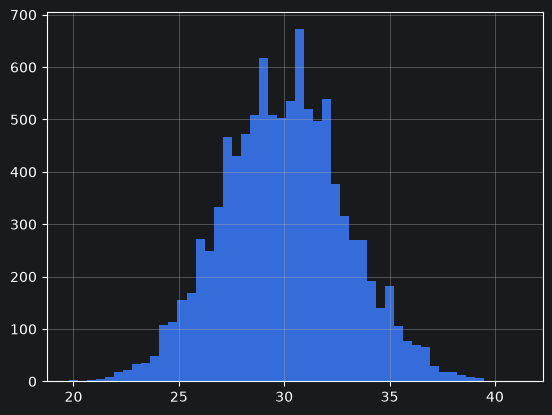

In [4]:
# Does the fuel efficiency distribution have a long tail?
df['fuel_efficiency_mpg'].hist(bins=50)

# The distribution is bell-shaped, there's no significant long tail to look at.

In [5]:
# Which column has missing values?
print(df.isnull().sum())

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64


In [6]:
# What's the median for variable 'horsepower'?
print(df['horsepower'].median())

254.0


In [7]:
# Datasets prepared for training, validation, and testing
def split_data(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    return df_train, df_val, df_test

def train_linear_regression(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

def predict(X, w0, w):
    return w0 + X.dot(w)

def rmse(y, y_pred):
    return np.sqrt(((y - y_pred) ** 2).mean())

features = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

def prepare_X(df, fillna_value):
    df = df.copy()
    df['horsepower'] = df['horsepower'].fillna(fillna_value)
    return df[features].values

### Question 3

Deal with missing values in `horsepower`: fill with 0 or with the mean (computed on the training set only). Compare the validation RMSE (rounded to 3 decimals).

In [8]:
# Which is better, filling with 0 or with the mean ?
df_train, df_val, df_test = split_data(df, 42)

y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values

# Option 1: fill with 0
X_train = prepare_X(df_train, 0)
w0, w = train_linear_regression(X_train, y_train)
rmse_zero = rmse(y_val, predict(prepare_X(df_val, 0), w0, w))

# Option 2: fill with the mean (computed on the training set)
hp_mean = df_train['horsepower'].mean()
X_train = prepare_X(df_train, hp_mean)
w0, w = train_linear_regression(X_train, y_train)
rmse_mean = rmse(y_val, predict(prepare_X(df_val, hp_mean), w0, w))

print('RMSE with 0    :', round(rmse_zero, 3))
print('RMSE with mean :', round(rmse_mean, 3))

RMSE with 0    : 2.205
RMSE with mean : 2.202


In [10]:
# Which has the best RMSE ?
df_train, df_val, df_test = split_data(df, 42)
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values

X_train = prepare_X(df_train, 0)
X_val = prepare_X(df_val, 0)

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression(X_train, y_train, r)
    score = rmse(y_val, predict(X_val, w0, w))
    print('r =', r, '-> RMSE =', round(score, 4))

r = 0 -> RMSE = 2.2053
r = 0.01 -> RMSE = 2.2058
r = 0.1 -> RMSE = 2.2241
r = 1 -> RMSE = 2.3492
r = 5 -> RMSE = 2.4094
r = 10 -> RMSE = 2.4195
r = 100 -> RMSE = 2.4292


In [12]:
# What's the values of std ?
scores = []
for seed in range(10):
    df_train, df_val, df_test = split_data(df, seed)
    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values

    X_train = prepare_X(df_train, 0)
    w0, w = train_linear_regression(X_train, y_train)
    scores.append(rmse(y_val, predict(prepare_X(df_val, 0), w0, w)))

print(scores)
print('std =', round(np.std(scores), 3))

[np.float64(2.2392041430511704), np.float64(2.2021128210833383), np.float64(2.163419778753089), np.float64(2.2043588768501907), np.float64(2.2018800943308556), np.float64(2.245785150908504), np.float64(2.2697212079514624), np.float64(2.1907945999364102), np.float64(2.216611201697255), np.float64(2.2070365928266966)]
std = 0.029


In [14]:
# What the RMSE of the test dataset ?
df_train, df_val, df_test = split_data(df, 9)

df_full_train = pd.concat([df_train, df_val])
y_full_train = df_full_train['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

X_full_train = prepare_X(df_full_train, 0)
w0, w = train_linear_regression(X_full_train, y_full_train, r=0.001)

score = rmse(y_test, predict(prepare_X(df_test, 0), w0, w))
print('RMSE test =', round(score, 3))

RMSE test = 2.236
